# Nahaufnahme im $(p,h)$-Diagramm

Für einen Stichprobenumfang $n$ verläuft das normalapproximative Prognoseband zwischen

$$
h=p\pm z\sqrt{\frac{p(1-p)}{n}}.
$$

Die Nahaufnahme stellt zwei Punkte mit derselben Realisation $h$ gegenüber. Die senkrechten Strecken zeigen jeweils den geometrischen Abstand $|h-p|$ zur Mittellinie $h=p$.

Die Grafik macht sichtbar, warum „geometrisch gleich weit entfernt“ nicht „stochastisch gleich weit“ bedeuten muss. Eine gesonderte Ergebniszeile gibt es nicht: Die Darstellung bleibt ein **Denkraum**.

## Eingaben

Nur die folgende Zelle muss verändert werden. Die Klasse `Config` bündelt vier Arten von Eingaben:

- mathematische Eingaben,
- Ausschnitt und Elemente der Grafik,
- Beschriftung,
- Anzeige und Speicherung.

Der Wert $z=1{,}64$ wird hier bewusst direkt eingegeben: Die Nahaufnahme schließt damit genau an die verwendete IQB-Fassung an. Die beiden Parameterwerte stehen gemeinsam in `p_values`.

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter
import numpy as np


plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})


@dataclass(frozen=True)
class Config:
    # Mathematische Eingaben
    n: int = 400
    z: float = 1.64
    h: float = 0.17
    p_values: tuple[float, ...] = (0.14, 0.20)

    # Ausschnitt und Elemente der Grafik
    axis_min: float = 0.13
    axis_max: float = 0.21
    grid_points: int = 2001
    show_prediction_band: bool = True
    show_midline: bool = True
    show_distance_lines: bool = True
    show_location_labels: bool = True
    point_size: float = 60.0

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True

    # Ausgabe des Notebooks
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung und mathematische Berechnung

Zunächst werden die Eingaben geprüft. Danach berechnet `calculate()` das Prognoseband, die beiden Punkte und ihre Lage zum Band. Alle Größen werden als Argumente übergeben; die mathematischen Funktionen greifen nicht auf globale Zwischenwerte zu.

Die Lage wird ausschließlich für die Darstellung benötigt. Sie wird weder als Zahl noch als gesonderte Ergebniszeile ausgegeben.

In [18]:
@dataclass(frozen=True)
class Calculation:
    p_grid: np.ndarray
    prediction_lower: np.ndarray
    prediction_upper: np.ndarray
    p_points: np.ndarray
    h_points: np.ndarray
    point_lower: np.ndarray
    point_upper: np.ndarray
    inside: np.ndarray
    distances: np.ndarray


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not np.isfinite(cfg.z) or cfg.z <= 0.0:
        raise ValueError("z muss positiv sein.")
    if not np.isfinite(cfg.h) or not 0.0 <= cfg.h <= 1.0:
        raise ValueError("h muss zwischen 0 und 1 liegen.")
    if len(cfg.p_values) < 1:
        raise ValueError("p_values muss mindestens einen Wert enthalten.")
    if any(not np.isfinite(value) for value in cfg.p_values):
        raise ValueError("Alle Werte in p_values müssen endlich sein.")
    if any(not 0.0 <= value <= 1.0 for value in cfg.p_values):
        raise ValueError("Alle Werte in p_values müssen zwischen 0 und 1 liegen.")
    if len(set(cfg.p_values)) != len(cfg.p_values):
        raise ValueError("Die Werte in p_values müssen verschieden sein.")

    if not 0.0 <= cfg.axis_min < cfg.axis_max <= 1.0:
        raise ValueError("Es muss 0 <= axis_min < axis_max <= 1 gelten.")
    if not cfg.axis_min <= cfg.h <= cfg.axis_max:
        raise ValueError("h liegt außerhalb des sichtbaren Ausschnitts.")
    if any(
        not cfg.axis_min <= value <= cfg.axis_max
        for value in cfg.p_values
    ):
        raise ValueError("Mindestens ein p-Wert liegt außerhalb des sichtbaren Ausschnitts.")
    if (
        not isinstance(cfg.grid_points, int)
        or isinstance(cfg.grid_points, bool)
        or cfg.grid_points < 2
    ):
        raise ValueError("grid_points muss eine ganze Zahl ab 2 sein.")
    if not np.isfinite(cfg.point_size) or cfg.point_size <= 0.0:
        raise ValueError("point_size muss positiv sein.")

    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")
    if Path(cfg.output_dir).is_absolute():
        raise ValueError("output_dir muss ein relativer Pfad sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    if cfg.save_figure and not formats:
        raise ValueError("save_formats darf beim Speichern nicht leer sein.")
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def prediction_bounds(
    p: np.ndarray,
    *,
    n: int,
    z: float,
) -> tuple[np.ndarray, np.ndarray]:
    half_width = z * np.sqrt(p * (1.0 - p) / n)
    return p - half_width, p + half_width


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    p_grid = np.linspace(cfg.axis_min, cfg.axis_max, cfg.grid_points)
    prediction_lower, prediction_upper = prediction_bounds(
        p_grid,
        n=cfg.n,
        z=cfg.z,
    )

    p_points = np.asarray(cfg.p_values, dtype=float)
    h_points = np.full(p_points.shape, cfg.h, dtype=float)
    point_lower, point_upper = prediction_bounds(
        p_points,
        n=cfg.n,
        z=cfg.z,
    )
    inside = (point_lower <= h_points) & (h_points <= point_upper)

    return Calculation(
        p_grid=p_grid,
        prediction_lower=prediction_lower,
        prediction_upper=prediction_upper,
        p_points=p_points,
        h_points=h_points,
        point_lower=point_lower,
        point_upper=point_upper,
        inside=inside,
        distances=np.abs(h_points - p_points),
    )

## Grafik

`create_figure()` erzeugt ausschließlich die Grafik. Prognoseband, Mittellinie, Abstandsstrecken sowie die Lagebezeichnungen können unabhängig voneinander ein- und ausgeblendet werden.

Titel und Untertitel sind ebenfalls getrennt schaltbar. Der Untertitel enthält nur Eingaben. Die mathematische Darstellung in der Mitte bleibt frei von einer zusätzlichen Ergebniszeile.

In [19]:
def format_decimal(value: float, _position: int) -> str:
    return f"{value:.2f}".replace(".", ",")


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[Figure, Axes]:
    fig, ax = plt.subplots(figsize=(7.0, 6.8))

    if cfg.show_prediction_band:
        ax.fill_between(
            calculation.p_grid,
            calculation.prediction_lower,
            calculation.prediction_upper,
            color="0.96",
            zorder=0,
        )
        ax.plot(
            calculation.p_grid,
            calculation.prediction_lower,
            color="0.45",
            linestyle=":",
            linewidth=2.2,
        )
        ax.plot(
            calculation.p_grid,
            calculation.prediction_upper,
            color="0.45",
            linestyle=":",
            linewidth=2.2,
        )

    if cfg.show_midline:
        ax.plot(
            calculation.p_grid,
            calculation.p_grid,
            color="0.68",
            linestyle="--",
            linewidth=1.5,
            zorder=1,
        )

    ax.axhline(cfg.h, color="0.55", linewidth=1.25, zorder=1)

    if cfg.show_distance_lines:
        for p_value, distance in zip(
            calculation.p_points,
            calculation.distances,
        ):
            ax.plot(
                [p_value, p_value],
                [p_value, cfg.h],
                color="0.48",
                linestyle=(0, (3, 3)),
                linewidth=1.35,
                zorder=2,
            )
            left_of_h = p_value < cfg.h
            ax.text(
                p_value + (-0.0015 if left_of_h else 0.0015),
                (p_value + cfg.h) / 2.0,
                f"{distance:.2f}".replace(".", ","),
                ha="right" if left_of_h else "left",
                va="center",
                fontsize=11,
                color="0.30",
            )

    ax.scatter(
        calculation.p_points[calculation.inside],
        calculation.h_points[calculation.inside],
        s=cfg.point_size,
        facecolors="white",
        edgecolors="black",
        linewidths=1.25,
        zorder=4,
    )
    ax.scatter(
        calculation.p_points[~calculation.inside],
        calculation.h_points[~calculation.inside],
        s=1.35 * cfg.point_size,
        facecolors="tab:red", 
        edgecolors="black",
        linewidths=1.3,
        zorder=5,
    )

    if cfg.show_location_labels:
        for p_value, is_inside in zip(
            calculation.p_points,
            calculation.inside,
        ):
            left_of_h = p_value < cfg.h
            ax.annotate(
                "innerhalb" if is_inside else "außerhalb",
                (p_value, cfg.h),
                xytext=(8 if left_of_h else 6, 10),
                textcoords="offset points",
                ha="right" if left_of_h else "left",
                va="bottom",
                fontsize=11,
            )

    if cfg.show_midline:
        diagonal_position = cfg.axis_min + 0.775 * (
            cfg.axis_max - cfg.axis_min
        )
        ax.text(
            diagonal_position,
            diagonal_position + 0.001,
            r"$h=p$",
            rotation=45,
            ha="center",
            va="bottom",
            fontsize=11,
            color="0.42",
        )

    ax.set(
        xlim=(cfg.axis_min, cfg.axis_max),
        ylim=(cfg.axis_min, cfg.axis_max),
        xlabel=r"$p$",
        ylabel=r"$h$",
    )
    ax.set_aspect("equal", adjustable="box")

    important_values = sorted({*cfg.p_values, cfg.h})
    ax.set_xticks(important_values)
    ax.set_yticks(important_values)
    ax.xaxis.set_major_formatter(FuncFormatter(format_decimal))
    ax.yaxis.set_major_formatter(FuncFormatter(format_decimal))

    ax.tick_params(axis="both", labelsize=11, length=4, width=0.8)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    for spine in ax.spines.values():
        spine.set_color("0.72")
        spine.set_linewidth(0.8)

    title = r"Nahaufnahme im $(p,h)$-Diagramm"
    p_text = r",\quad ".join(
        f"{value:.2f}" for value in cfg.p_values
    )
    subtitle = (
        rf"$n={cfg.n},\quad z={cfg.z:.2f},\quad h={cfg.h:.2f};\quad "
        rf"p={p_text}$"
    )

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=16, pad=35)
        ax.text(
            0.5,
            1.03,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=12,
            color="0.35",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=16, pad=13)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=11, color="0.35", pad=13)

    fig.tight_layout()
    return fig, ax

## Ausgabe

Berechnung, Erzeugung der Grafik sowie Anzeige und Speicherung bleiben getrennt. Die Grafik kann unabhängig voneinander angezeigt und gespeichert werden.

Ist `save_figure = True`, wird der relative Unterordner `fig/` bei Bedarf automatisch angelegt. PNG- und PDF-Dateien werden dort gesammelt; das Verzeichnis des Notebooks bleibt frei von einzelnen Grafikdateien.

Der Dateiname wird automatisch aus den mathematischen Eingaben gebildet. Für die Standardeinstellungen entstehen

- `Nahaufnahme-ph-Raum-n400-h017-p014-p020-z164.png`,
- `Nahaufnahme-ph-Raum-n400-h017-p014-p020-z164.pdf`.

Die letzte Zelle zeigt ausschließlich die Grafik. Eine zusätzliche Ergebniszeile wird bewusst nicht ausgegeben.

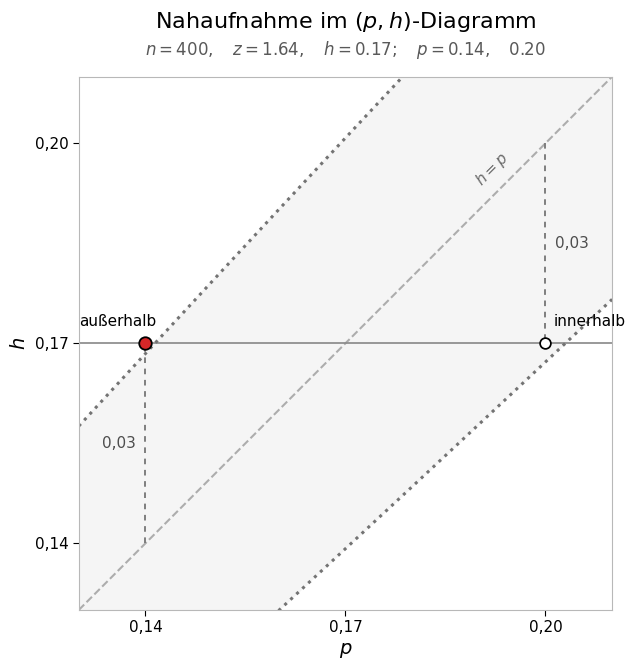

In [20]:
def number_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    integer, separator, decimals = text.partition(".")
    decimals = decimals.ljust(2, "0") if separator else "00"
    return f"{integer}{decimals}".replace("-", "m")


def figure_stem(cfg: Config) -> str:
    p_part = "-".join(
        f"p{number_token(value)}" for value in cfg.p_values
    )
    return (
        f"Nahaufnahme-ph-Raum-n{cfg.n}-h{number_token(cfg.h)}-"
        f"{p_part}-z{number_token(cfg.z)}"
    )


def save_figure(
    fig: Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)